# 06 — Explainability SHAP

Carrega els models entrenats pel **05_ML_pipeline** i analitza per què prediu el que prediu.

| Secció | Pregunta |
|--------|----------|
| 1 | Diagnòstic de residus (pred vs real) |
| 2 | SHAP global — beeswarm Modelo B |
| 3 | SHAP comparatiu A vs B — on va el pes quan hi ha lags |
| 4 | SHAP waterfall — hora de pic i hora de mínim |
| 5 | SHAP per tipus de dia — lectiu vs no lectiu |
| 6 | SHAP dependence plots — top 3 features |

**Input**: `outputs/models/xgboost_modelo_B_causal.pkl` (exportat pel 05)  
**Output**: figures a `outputs/figures/`

In [1]:
import warnings; warnings.filterwarnings('ignore')
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import shap
from pathlib import Path
from sklearn.metrics import r2_score, mean_absolute_error

MODELS  = Path('../outputs/models')
FIGURES = Path('../outputs/figures')
FIGURES.mkdir(parents=True, exist_ok=True)

sns.set_theme(style='whitegrid', font_scale=1.1)
print('OK')

OK


In [2]:
# ── Carregar models i artefactes (exportats pel 05) ──────────────────────────
xgb_B = joblib.load(MODELS / 'xgboost_modelo_B_causal.pkl')
xgb_A = joblib.load(MODELS / 'xgboost_modelo_A_operativo.pkl')

feat_B    = joblib.load(MODELS / 'X_test_columns.pkl')
feat_A    = joblib.load(MODELS / 'X_test_columns_A.pkl')

X_te_B    = pd.DataFrame(np.load(MODELS / 'X_test_B.npy'),  columns=feat_B)
X_te_A    = pd.DataFrame(np.load(MODELS / 'X_test_A.npy'),  columns=feat_A)
X_tr_B    = pd.DataFrame(np.load(MODELS / 'X_train_B.npy'), columns=feat_B)
y_te      = np.load(MODELS / 'y_test.npy')
pred_B    = np.load(MODELS / 'predictions_B.npy')
pred_A    = np.load(MODELS / 'predictions_A.npy')
tipus_te  = np.load(MODELS / 'tipus_dia_test.npy', allow_pickle=True)

r2_B  = r2_score(y_te, pred_B)
mae_B = mean_absolute_error(y_te, pred_B)
r2_A  = r2_score(y_te, pred_A)

print(f'Modelo B carregat:  {X_te_B.shape}  R²={r2_B:.4f}  MAE={mae_B:.1f} kWh')
print(f'Modelo A carregat:  {X_te_A.shape}  R²={r2_A:.4f}')
print(f'Tipus de dia únics en test: {np.unique(tipus_te)}')

Modelo B carregat:  (1750, 30)  R²=0.9524  MAE=16.2 kWh
Modelo A carregat:  (1750, 32)  R²=0.9910
Tipus de dia únics en test: ['Avaluacio' 'Classe' 'Dissabte' 'Diumenge' 'Festiu' 'No lectiu'
 'Vacances']


## Secció 1 — Diagnòstic de residus

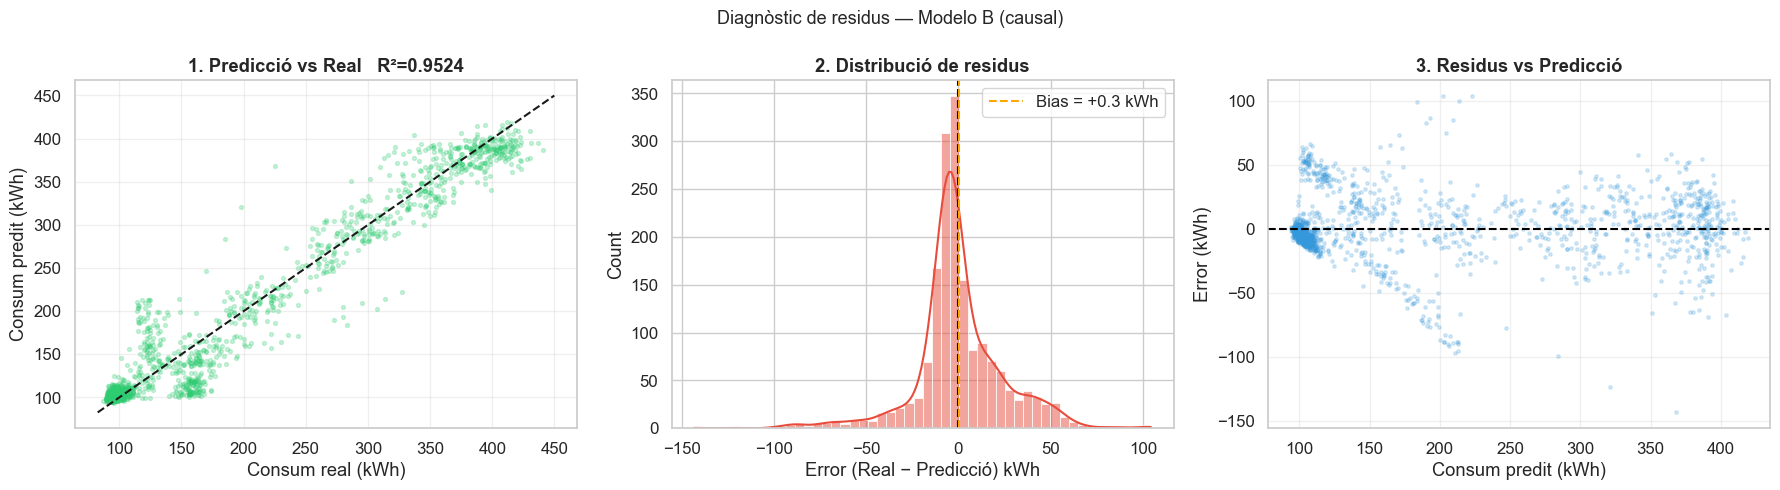

Bias: +0.30 kWh
σ residus: 24.29 kWh
% residus |e|<20 kWh: 73.8%
✅ shap_residual_diagnostics.png


In [3]:
errors = y_te - pred_B

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 1. Predicho vs Real
axes[0].scatter(y_te, pred_B, alpha=0.25, s=8, color='#2ecc71')
lim = [y_te.min()*0.95, y_te.max()*1.02]
axes[0].plot(lim, lim, 'k--', lw=1.5)
axes[0].set_title(f'1. Predicció vs Real   R²={r2_B:.4f}', fontweight='bold')
axes[0].set_xlabel('Consum real (kWh)'); axes[0].set_ylabel('Consum predit (kWh)')
axes[0].grid(alpha=0.3)

# 2. Distribució de residus
sns.histplot(errors, bins=50, kde=True, ax=axes[1], color='#e74c3c')
axes[1].axvline(0, color='black', ls='--', lw=1.5)
axes[1].axvline(errors.mean(), color='orange', ls='--', lw=1.5,
                 label=f'Bias = {errors.mean():+.1f} kWh')
axes[1].set_title('2. Distribució de residus', fontweight='bold')
axes[1].set_xlabel('Error (Real − Predicció) kWh'); axes[1].legend()

# 3. Residus vs predicció (heteroscedasticitat?)
axes[2].scatter(pred_B, errors, alpha=0.2, s=6, color='#3498db')
axes[2].axhline(0, color='black', ls='--', lw=1.5)
axes[2].set_title('3. Residus vs Predicció', fontweight='bold')
axes[2].set_xlabel('Consum predit (kWh)'); axes[2].set_ylabel('Error (kWh)')
axes[2].grid(alpha=0.3)

plt.suptitle('Diagnòstic de residus — Modelo B (causal)', fontsize=13)
plt.tight_layout()
plt.savefig(FIGURES / 'shap_residual_diagnostics.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'Bias: {errors.mean():+.2f} kWh')
print(f'σ residus: {errors.std():.2f} kWh')
print(f'% residus |e|<20 kWh: {(np.abs(errors)<20).mean()*100:.1f}%')
print('✅ shap_residual_diagnostics.png')

## Secció 2 — SHAP global (beeswarm) — Modelo B

Calculant SHAP values Modelo B (pot trigar uns minuts)...
SHAP calculats: (1750, 30)


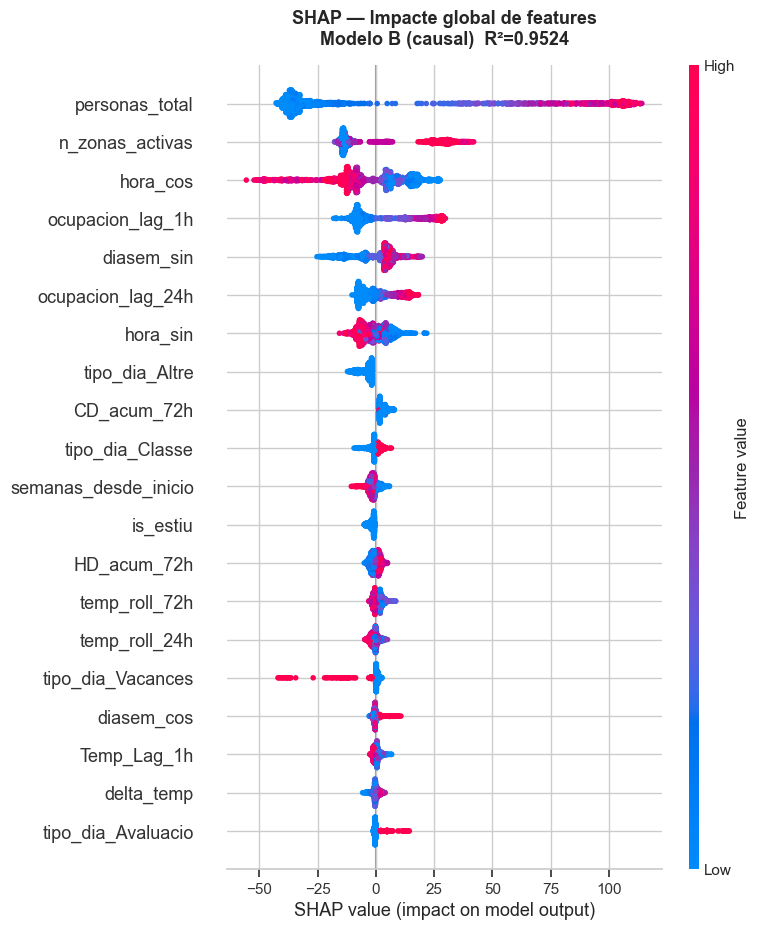

✅ shap_beeswarm_B.png


In [4]:
print('Calculant SHAP values Modelo B (pot trigar uns minuts)...')
explainer_B = shap.TreeExplainer(xgb_B)
sv_B        = explainer_B(X_te_B)      # Explanation object (inclou base_values)
shap_vals_B = sv_B.values              # numpy array (n_samples, n_features)
print(f'SHAP calculats: {shap_vals_B.shape}')

# ── Beeswarm: impacte global + direcció ──────────────────────────────────────
plt.figure(figsize=(11, 8))
shap.summary_plot(sv_B, X_te_B, max_display=20, show=False)
plt.title(f'SHAP — Impacte global de features\nModelo B (causal)  R²={r2_B:.4f}',
           fontsize=13, fontweight='bold', pad=15)
plt.tight_layout()
plt.savefig(FIGURES / 'shap_beeswarm_B.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ shap_beeswarm_B.png')

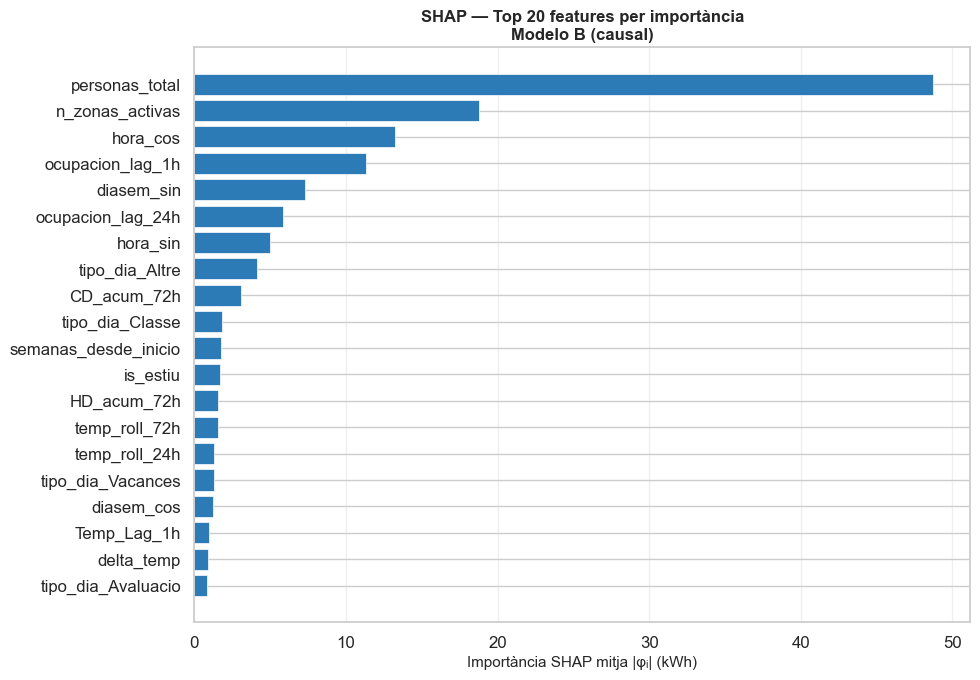

Top 10 features per importància SHAP:
  personas_total                : 48.747 kWh
  n_zonas_activas               : 18.794 kWh
  hora_cos                      : 13.219 kWh
  ocupacion_lag_1h              : 11.306 kWh
  diasem_sin                    : 7.301 kWh
  ocupacion_lag_24h             : 5.841 kWh
  hora_sin                      : 4.974 kWh
  tipo_dia_Altre                : 4.127 kWh
  CD_acum_72h                   : 3.102 kWh
  tipo_dia_Classe               : 1.844 kWh
✅ shap_bar_B.png


In [5]:
# ── Bar plot: importància mitja absoluta ─────────────────────────────────────
# Top 20 features per importància SHAP
shap_mean_abs = np.abs(shap_vals_B).mean(axis=0)
shap_imp = pd.Series(shap_mean_abs, index=feat_B).sort_values(ascending=True).tail(20)

fig, ax = plt.subplots(figsize=(10, 7))
ax.barh(shap_imp.index, shap_imp.values, color='#2c7bb6', edgecolor='white', lw=0.5)
ax.set_xlabel('Importància SHAP mitja |φᵢ| (kWh)', fontsize=11)
ax.set_title('SHAP — Top 20 features per importància\nModelo B (causal)',
              fontsize=12, fontweight='bold')
ax.grid(alpha=0.3, axis='x')
plt.tight_layout()
plt.savefig(FIGURES / 'shap_bar_B.png', dpi=150, bbox_inches='tight')
plt.show()

print('Top 10 features per importància SHAP:')
for feat, imp in shap_imp.tail(10).sort_values(ascending=False).items():
    print(f'  {feat:30s}: {imp:.3f} kWh')
print('✅ shap_bar_B.png')

## Secció 3 — SHAP comparatiu A vs B

Calculant SHAP values Modelo A...
OK


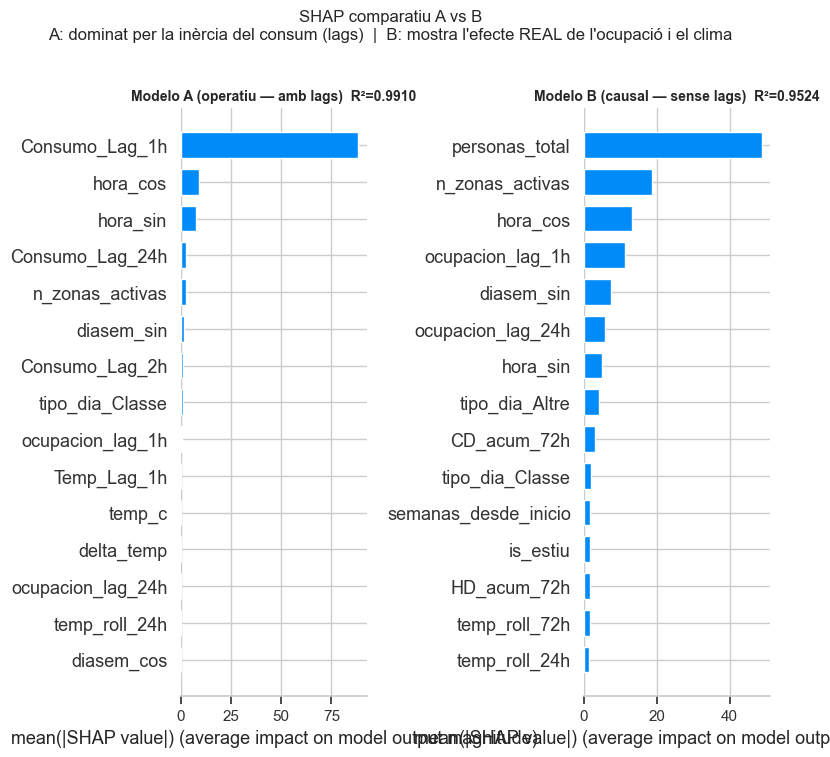

✅ shap_comparacio_AB.png

Interpretació:
  Si Consumo_Lag_1h domina el Modelo A → el model A aprèn principalment inèrcia.
  El Modelo B revela el pes REAL: quant contribueix ocupació vs temperatura vs hora.


In [6]:
print('Calculant SHAP values Modelo A...')
explainer_A = shap.TreeExplainer(xgb_A)
sv_A        = explainer_A(X_te_A)
shap_vals_A = sv_A.values
print('OK')

fig, axes = plt.subplots(1, 2, figsize=(20, 8))

for ax, sv, X_te, label in [
    (axes[0], sv_A, X_te_A, f'Modelo A (operatiu — amb lags)  R²={r2_A:.4f}'),
    (axes[1], sv_B, X_te_B, f'Modelo B (causal — sense lags)  R²={r2_B:.4f}'),
]:
    plt.sca(ax)
    shap.summary_plot(sv, X_te, plot_type='bar', show=False, max_display=15)
    ax.set_title(label, fontsize=10, fontweight='bold')

plt.suptitle(
    'SHAP comparatiu A vs B\n'
    'A: dominat per la inèrcia del consum (lags)  |  '
    'B: mostra l\'efecte REAL de l\'ocupació i el clima',
    fontsize=12, y=1.01
)
plt.tight_layout()
plt.savefig(FIGURES / 'shap_comparacio_AB.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ shap_comparacio_AB.png')
print()
print('Interpretació:')
print('  Si Consumo_Lag_1h domina el Modelo A → el model A aprèn principalment inèrcia.')
print('  El Modelo B revela el pes REAL: quant contribueix ocupació vs temperatura vs hora.')

## Secció 4 — SHAP waterfall: hora de pic i hora de mínim

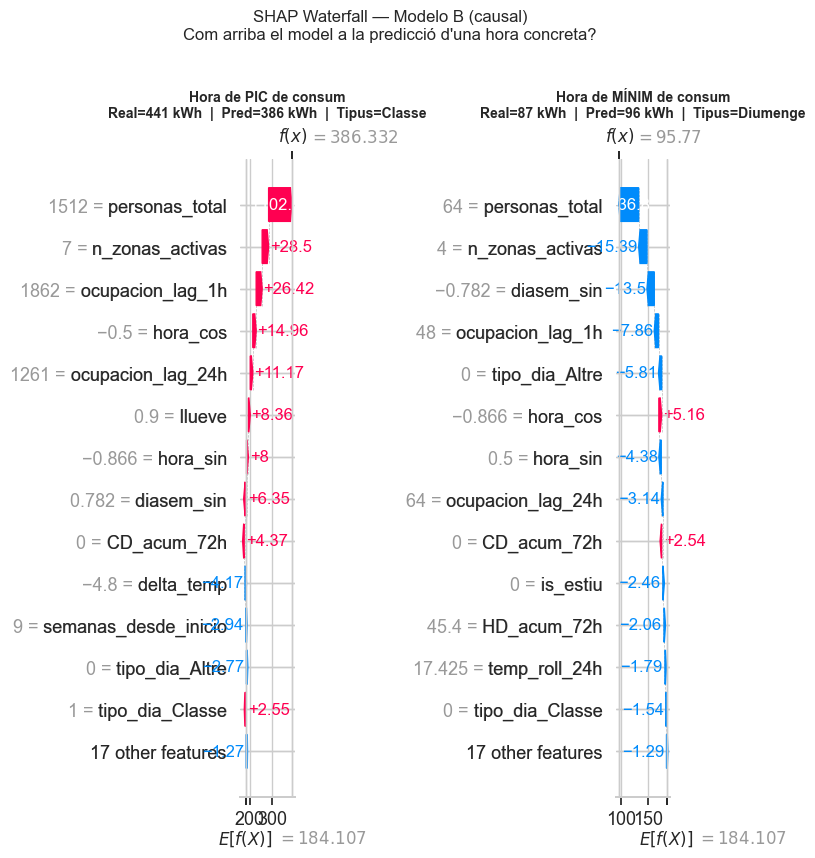

✅ shap_waterfall_pic_min.png


In [7]:
idx_pic  = y_te.argmax()
idx_min  = y_te.argmin()

fig, axes = plt.subplots(1, 2, figsize=(20, 7))

for ax, idx, descrip in [
    (axes[0], idx_pic, 'Hora de PIC de consum'),
    (axes[1], idx_min, 'Hora de MÍNIM de consum'),
]:
    plt.sca(ax)
    shap.plots.waterfall(sv_B[idx], max_display=14, show=False)
    ax.set_title(
        f'{descrip}\n'
        f'Real={y_te[idx]:.0f} kWh  |  Pred={pred_B[idx]:.0f} kWh  |  '
        f'Tipus={tipus_te[idx]}',
        fontsize=10, fontweight='bold'
    )

plt.suptitle('SHAP Waterfall — Modelo B (causal)\n'
              'Com arriba el model a la predicció d\'una hora concreta?',
              fontsize=12, y=1.01)
plt.tight_layout()
plt.savefig(FIGURES / 'shap_waterfall_pic_min.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ shap_waterfall_pic_min.png')

## Secció 5 — SHAP per tipus de dia: lectiu vs no lectiu

Hores lectius en test:     1009
Hores no lectius en test:  741


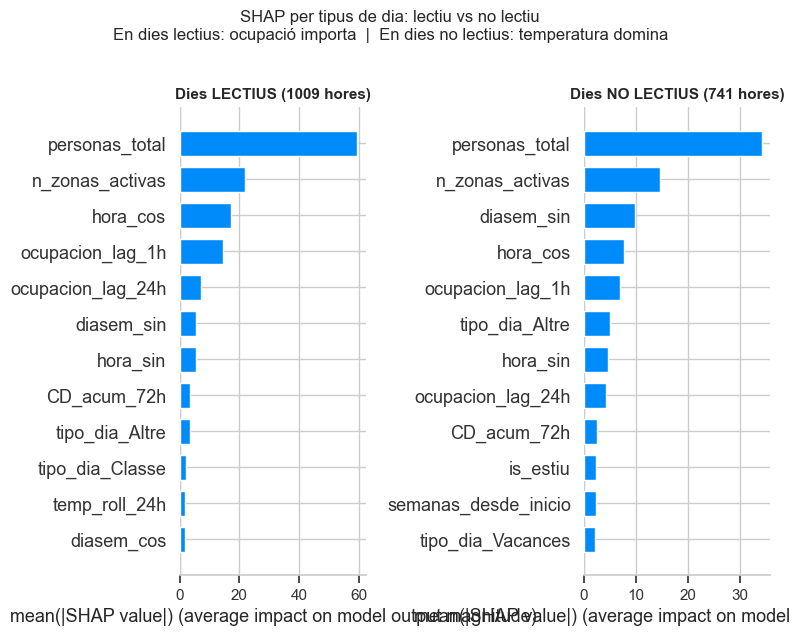


Importància SHAP de personas_total:
  Dies lectius:     59.517 kWh
  Dies no lectius:  34.081 kWh
  Ràtio:            1.7×
✅ shap_per_tipus_dia.png


In [8]:
LECTIUS    = ['Classe','Avaluacio','No lectiu','La Benvinguda']
NO_LECTIUS = ['Vacances','Autre','Alte','Autre_Estiu','Dissabte','Diumenge','Festiu']

mask_lect = np.isin(tipus_te, LECTIUS)
mask_nol  = ~mask_lect

print(f'Hores lectius en test:     {mask_lect.sum()}')
print(f'Hores no lectius en test:  {mask_nol.sum()}')

fig, axes = plt.subplots(1, 2, figsize=(20, 8))

for ax, mask, titol in [
    (axes[0], mask_lect, f'Dies LECTIUS ({mask_lect.sum()} hores)'),
    (axes[1], mask_nol,  f'Dies NO LECTIUS ({mask_nol.sum()} hores)'),
]:
    if mask.sum() < 10:
        ax.set_title(f'{titol} — massa poques dades'); continue
    plt.sca(ax)
    shap.summary_plot(
        shap_vals_B[mask],
        X_te_B.iloc[mask],
        plot_type='bar', show=False, max_display=12
    )
    ax.set_title(titol, fontsize=11, fontweight='bold')

plt.suptitle(
    'SHAP per tipus de dia: lectiu vs no lectiu\n'
    'En dies lectius: ocupació importa  |  En dies no lectius: temperatura domina',
    fontsize=12, y=1.01
)
plt.tight_layout()
plt.savefig(FIGURES / 'shap_per_tipus_dia.png', dpi=150, bbox_inches='tight')
plt.show()

# Importància relativa de personas_total en cada context
feat_pers = 'personas_total'
if feat_pers in feat_B:
    idx_p = feat_B.index(feat_pers)
    imp_lect = np.abs(shap_vals_B[mask_lect, idx_p]).mean()
    imp_nol  = np.abs(shap_vals_B[mask_nol,  idx_p]).mean() if mask_nol.sum() > 0 else 0
    print(f'\nImportància SHAP de {feat_pers}:')
    print(f'  Dies lectius:     {imp_lect:.3f} kWh')
    print(f'  Dies no lectius:  {imp_nol:.3f} kWh')
    print(f'  Ràtio:            {imp_lect/max(imp_nol,0.001):.1f}×')
print('✅ shap_per_tipus_dia.png')

## Secció 6 — SHAP dependence plots (top 3 features)

Top 3 features SHAP: ['personas_total', 'n_zonas_activas', 'hora_cos']


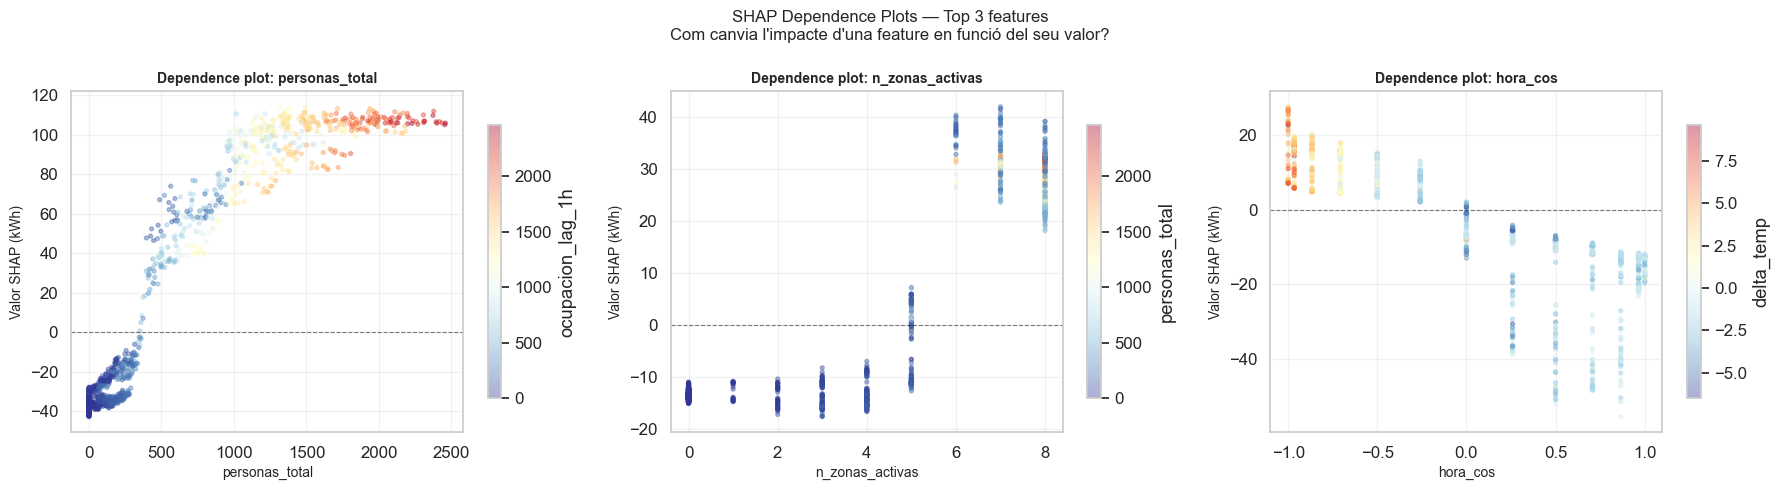

✅ shap_dependence_top3.png


In [9]:
# Top 3 features per importància SHAP
top3 = pd.Series(np.abs(shap_vals_B).mean(axis=0), index=feat_B)\
         .sort_values(ascending=False).head(3).index.tolist()
print(f'Top 3 features SHAP: {top3}')

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, feat in zip(axes, top3):
    # Feature d'interacció: la que té correlació absoluta més alta amb els valors SHAP
    corrs = [
        (f, abs(np.corrcoef(X_te_B[f].values, shap_vals_B[:, feat_B.index(feat)])[0,1]))
        for f in feat_B if f != feat
    ]
    interact = max(corrs, key=lambda x: x[1])[0]

    sc = ax.scatter(
        X_te_B[feat].values,
        shap_vals_B[:, feat_B.index(feat)],
        c=X_te_B[interact].values,
        cmap='RdYlBu_r', alpha=0.4, s=8
    )
    plt.colorbar(sc, ax=ax, label=interact, shrink=0.8)
    ax.axhline(0, color='black', lw=0.8, ls='--', alpha=0.5)
    ax.set_xlabel(feat, fontsize=10)
    ax.set_ylabel('Valor SHAP (kWh)', fontsize=10)
    ax.set_title(f'Dependence plot: {feat}', fontweight='bold', fontsize=10)
    ax.grid(alpha=0.25)

plt.suptitle('SHAP Dependence Plots — Top 3 features\n'
              'Com canvia l\'impacte d\'una feature en funció del seu valor?',
              fontsize=12)
plt.tight_layout()
plt.savefig(FIGURES / 'shap_dependence_top3.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ shap_dependence_top3.png')

In [10]:
# ── Resum executiu ────────────────────────────────────────────────────────────
print('═'*60)
print('RESUM SHAP — MODELO B (CAUSAL)')
print('═'*60)
print(f'\nR²={r2_B:.4f}  MAE={mae_B:.1f} kWh  Bias={errors.mean():+.2f} kWh')
print(f'\nTop 5 features per importància SHAP:')
top5 = pd.Series(np.abs(shap_vals_B).mean(axis=0), index=feat_B)\
         .sort_values(ascending=False).head(5)
for feat, imp in top5.items():
    print(f'  {feat:30s}: {imp:.3f} kWh')

if 'personas_total' in feat_B:
    idx_p = feat_B.index('personas_total')
    rang_p = shap_vals_B[:, idx_p]
    print(f'\nEfecte de personas_total:')
    print(f'  SHAP mig absolut: {np.abs(rang_p).mean():.3f} kWh')
    print(f'  Rang [min,max]:   [{rang_p.min():.1f}, {rang_p.max():.1f}] kWh')
    print(f'  → Afegir 100 persones → +{np.polyfit(X_te_B["personas_total"], rang_p, 1)[0]*100:.1f} kWh estimats')

print()
figs_generats = ['shap_residual_diagnostics.png','shap_beeswarm_B.png',
                  'shap_bar_B.png','shap_comparacio_AB.png',
                  'shap_waterfall_pic_min.png','shap_per_tipus_dia.png',
                  'shap_dependence_top3.png']
for f in figs_generats:
    exists = '✅' if (FIGURES/f).exists() else '❌'
    print(f'  {exists} {f}')
print('═'*60)

════════════════════════════════════════════════════════════
RESUM SHAP — MODELO B (CAUSAL)
════════════════════════════════════════════════════════════

R²=0.9524  MAE=16.2 kWh  Bias=+0.30 kWh

Top 5 features per importància SHAP:
  personas_total                : 48.747 kWh
  n_zonas_activas               : 18.794 kWh
  hora_cos                      : 13.219 kWh
  ocupacion_lag_1h              : 11.306 kWh
  diasem_sin                    : 7.301 kWh

Efecte de personas_total:
  SHAP mig absolut: 48.747 kWh
  Rang [min,max]:   [-42.8, 114.1] kWh
  → Afegir 100 persones → +8.6 kWh estimats

  ✅ shap_residual_diagnostics.png
  ✅ shap_beeswarm_B.png
  ✅ shap_bar_B.png
  ✅ shap_comparacio_AB.png
  ✅ shap_waterfall_pic_min.png
  ✅ shap_per_tipus_dia.png
  ✅ shap_dependence_top3.png
════════════════════════════════════════════════════════════
